# Post Lab Task - Experiment 7

## Perform K-Fold Cross-Validation and Grid Search on Titanic Dataset

### Subtask 1: Data Acquisition and Preprocessing

**Concept:** Load the Titanic dataset, select relevant passenger features, handle missing values, encode categorical variables, and prepare the feature and target data for model validation.

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [6]:
titanic_df = pd.read_csv(titanic_url)

In [7]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

In [8]:
X_titanic = titanic_df[features].copy()

In [9]:
y_titanic = titanic_df['Survived']

In [10]:
X_titanic['Age'] = X_titanic['Age'].fillna(
    X_titanic['Age'].median()
)

In [11]:
X_titanic['Embarked'] = X_titanic['Embarked'].fillna(
    X_titanic['Embarked'].mode()[0]
)

In [12]:
X_titanic = pd.get_dummies(
    X_titanic,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

In [13]:
print("Titanic dataset prepared successfully.")
print("Feature Dataset Shape:", X_titanic.shape)

Titanic dataset prepared successfully.
Feature Dataset Shape: (891, 8)


In [14]:
print("\nTarget Distribution:")
print(y_titanic.value_counts())


Target Distribution:
Survived
0    549
1    342
Name: count, dtype: int64


### Subtask 2: Implementing Stratified K-Fold Cross-Validation

**Concept:** Apply Stratified K-Fold Cross-Validation to evaluate a Random Forest classifier across multiple folds while preserving the survival class distribution in each fold.

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [17]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [18]:
cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [19]:
cv_scores = cross_val_score(
    rf_model,
    X_titanic,
    y_titanic,
    cv=cv_strategy,
    scoring='accuracy'
)

In [20]:
print("10-Fold Stratified CV Accuracy Scores:")
print(cv_scores.round(4))

10-Fold Stratified CV Accuracy Scores:
[0.8333 0.809  0.7978 0.8315 0.7865 0.8539 0.8427 0.809  0.8202 0.8427]


In [21]:
print(
    f"\nMean Cross-Validation Accuracy: "
    f"{cv_scores.mean() * 100:.2f}%"
)


Mean Cross-Validation Accuracy: 82.27%


In [22]:
print(
    f"Standard Deviation of CV Accuracy: "
    f"{cv_scores.std() * 100:.2f}%"
)

Standard Deviation of CV Accuracy: 2.07%


### Subtask 3: Visualizing Cross-Validation Score Variance

**Concept:** Plot the accuracy scores obtained from each cross-validation fold to examine the variation and stability of the Random Forest model.

In [23]:
import matplotlib.pyplot as plt

In [24]:
import seaborn as sns

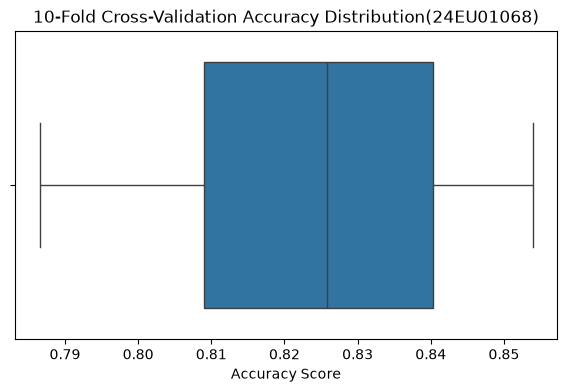

In [26]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    x=cv_scores
)

plt.title("10-Fold Cross-Validation Accuracy Distribution(24EU01068)")
plt.xlabel("Accuracy Score")

plt.show()

### Subtask 4: Preparing Training and Testing Data for Grid Search

**Concept:** Perform a stratified train-test split so that Grid Search can optimize the model using only the training data while the test set remains unseen for final evaluation.

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

In [29]:
print("Training Set Shape:", X_train_t.shape)
print("Testing Set Shape:", X_test_t.shape)

Training Set Shape: (712, 8)
Testing Set Shape: (179, 8)


### Subtask 5: Establishing the Baseline Random Forest Classifier

**Concept:** Train a Random Forest classifier using its default hyperparameters to establish a baseline performance before hyperparameter optimization.

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
rf_baseline = RandomForestClassifier(
    random_state=42
)

In [32]:
rf_baseline.fit(
    X_train_t,
    y_train_t
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [33]:
baseline_preds = rf_baseline.predict(
    X_test_t
)

In [34]:
baseline_accuracy = accuracy_score(
    y_test_t,
    baseline_preds
)

In [35]:
print(
    f"Default Random Forest Test Accuracy: "
    f"{baseline_accuracy * 100:.2f}%"
)

Default Random Forest Test Accuracy: 81.56%


### Subtask 6: Implementing Hyperparameter Tuning with Grid Search

**Concept:** Perform Grid Search Cross-Validation over multiple Random Forest hyperparameters to identify the model configuration that provides the highest validation accuracy.

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [38]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [39]:
grid_search.fit(
    X_train_t,
    y_train_t
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [40]:
print("Optimal Hyperparameters Selected via Grid Search:")
print(grid_search.best_params_)

Optimal Hyperparameters Selected via Grid Search:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [41]:
print(
    f"\nBest Grid Search Cross-Validation Accuracy: "
    f"{grid_search.best_score_ * 100:.2f}%"
)


Best Grid Search Cross-Validation Accuracy: 82.74%


### Subtask 7: Evaluating the Grid-Search Optimized Model

**Concept:** Evaluate the best Random Forest model selected by Grid Search on the unseen Titanic test set using accuracy, confusion matrix, and classification report.

In [42]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [44]:
best_rf_grid = grid_search.best_estimator_

In [45]:
grid_preds = best_rf_grid.predict(
    X_test_t
)

In [46]:
grid_accuracy = accuracy_score(
    y_test_t,
    grid_preds
)

In [47]:
print(
    f"Grid-Search Optimized Random Forest Test Accuracy: "
    f"{grid_accuracy * 100:.2f}%\n"
)

Grid-Search Optimized Random Forest Test Accuracy: 78.77%



In [48]:
print("--- Classification Report ---")
print(
    classification_report(
        y_test_t,
        grid_preds,
        target_names=['Not Survived', 'Survived']
    )
)

--- Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.78      0.91      0.84       110
    Survived       0.80      0.59      0.68        69

    accuracy                           0.79       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.79      0.79      0.78       179



### Subtask 8: Visualizing the Confusion Matrix

**Concept:** Visualize the confusion matrix of the optimized Random Forest model to examine correct and incorrect survival predictions.

In [49]:
cm = confusion_matrix(
    y_test_t,
    grid_preds
)

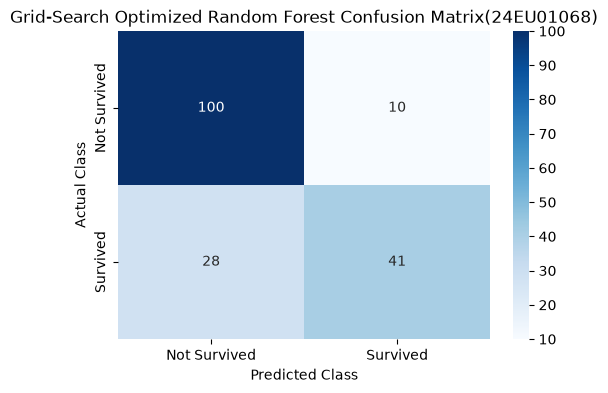

In [51]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title("Grid-Search Optimized Random Forest Confusion Matrix(24EU01068)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

### Subtask 9: Comparing Baseline and Grid-Search Model Performance

**Concept:** Compare the test accuracy of the default Random Forest classifier with the Grid-Search optimized model to observe the effect of hyperparameter optimization.

In [52]:
comparison_df = pd.DataFrame({
    'Model': [
        'Default Random Forest',
        'Grid-Search Random Forest'
    ],
    'Test Accuracy': [
        baseline_accuracy,
        grid_accuracy
    ]
})

In [53]:
print("--- Model Performance Comparison ---")
print(comparison_df.round(4))

--- Model Performance Comparison ---
                       Model  Test Accuracy
0      Default Random Forest         0.8156
1  Grid-Search Random Forest         0.7877


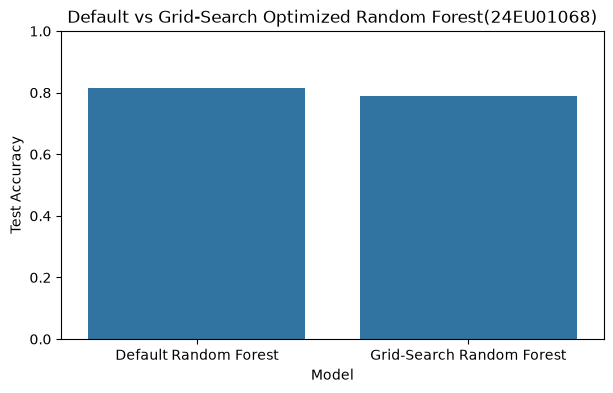

In [54]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Test Accuracy'
)

plt.title("Default vs Grid-Search Optimized Random Forest(24EU01068)")
plt.ylabel("Test Accuracy")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.show()